### **Import Libraries** ##

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, ttest_ind
import plotly.express as px
import plotly

### **Load Dataset** ##

In [43]:
df = pd.read_csv('E:\\Global-Terrorism-EDA-Project Final\\Data\\raw data\\global_terrorism.csv', encoding='ISO-8859-1')
df.head()

C:\Users\Lakshana\AppData\Local\Temp\ipykernel_4840\949658179.py:1: DtypeWarning:

Columns (0: approxdate, 1: resolution, 2: attacktype2_txt, 3: attacktype3_txt, 4: gsubname2, 5: gname3, 6: gsubname3, 7: claimmode2_txt, 8: claimmode3_txt, 9: weaptype3_txt, 10: weapsubtype3_txt, 11: weaptype4_txt, 12: weapsubtype4_txt, 13: divert, 14: kidhijcountry, 15: ransomnote) have mixed types. Specify dtype option on import or set low_memory=False.



,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [44]:
df_raw = df.copy()   # untouched backup 

### **Data Understanding** ##

In [45]:
df.shape

(181691, 135)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), str(58)
memory usage: 187.1 MB


In [47]:
df.dtypes

eventid       int64
iyear         int64
imonth        int64
iday          int64
approxdate      str
              ...  
INT_LOG       int64
INT_IDEO      int64
INT_MISC      int64
INT_ANY       int64
related         str
Length: 135, dtype: object

In [48]:
df.describe(include='all')

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
count,1.816910e+05,181691.000000,181691.000000,181691.000000,9239,181691.000000,2220,181691.000000,181691,181691.000000,...,28289,115500,76933,43516,181691,181691.000000,181691.000000,181691.000000,181691.000000,25038
unique,NaN,NaN,NaN,NaN,2244,NaN,1859,NaN,205,NaN,...,15429,83988,62263,36090,26,NaN,NaN,NaN,NaN,14306
top,NaN,NaN,NaN,NaN,"September 18-24, 2016",NaN,8/4/1998,NaN,Iraq,NaN,...,Casualty numbers for this incident conflict ac...,Committee on Government Operations United Stat...,"Christopher Hewitt, ""Political Violence and Te...","Christopher Hewitt, ""Political Violence and Te...",START Primary Collection,NaN,NaN,NaN,NaN,"201612010023, 201612010024, 201612010025, 2016..."
freq,NaN,NaN,NaN,NaN,101,NaN,18,NaN,24636,NaN,...,1607,205,134,139,78002,NaN,NaN,NaN,NaN,80
mean,2.002705e+11,2002.638997,6.467277,15.505644,NaN,0.045346,NaN,131.968501,NaN,7.160938,...,NaN,NaN,NaN,NaN,NaN,-4.543731,-4.464398,0.090010,-3.945952,NaN
std,1.325957e+09,13.259430,3.388303,8.814045,NaN,0.208063,NaN,112.414535,NaN,2.933408,...,NaN,NaN,NaN,NaN,NaN,4.543547,4.637152,0.568457,4.691325,NaN
min,1.970000e+11,1970.000000,0.000000,0.000000,NaN,0.000000,NaN,4.000000,NaN,1.000000,...,NaN,NaN,NaN,NaN,NaN,-9.000000,-9.000000,-9.000000,-9.000000,NaN
25%,1.991021e+11,1991.000000,4.000000,8.000000,NaN,0.000000,NaN,78.000000,NaN,5.000000,...,NaN,NaN,NaN,NaN,NaN,-9.000000,-9.000000,0.000000,-9.000000,NaN
50%,2.009022e+11,2009.000000,6.000000,15.000000,NaN,0.000000,NaN,98.000000,NaN,6.000000,...,NaN,NaN,NaN,NaN,NaN,-9.000000,-9.000000,0.000000,0.000000,NaN
75%,2.014081e+11,2014.000000,9.000000,23.000000,NaN,0.000000,NaN,160.000000,NaN,10.000000,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN


### **Data Preprocessing and Cleaning** ##

### Column Filtering ##

In [49]:
columns_to_keep = [
    'eventid','iyear','imonth','iday','extended',
    'country_txt','region_txt','provstate','city',
    'success','suicide',
    'attacktype1','attacktype1_txt',
    'targtype1','targtype1_txt',
    'gname','individual',
    'weaptype1_txt',
    'nkill','nwound','property'
]

df = df[columns_to_keep].copy()
df.shape

(181691, 21)

### Column Renaming ##

In [50]:
df.rename(columns={
    'eventid': 'Event_ID',
    'iyear': 'Year',
    'imonth': 'Month',
    'iday': 'Day',
    'extended': 'Extended',
    'country_txt': 'Country',
    'region_txt': 'Region',
    'provstate': 'State_Province',
    'city': 'City',
    'success': 'Success',
    'suicide': 'Suicide',
    'attacktype1': 'Attack_Type_Code',
    'attacktype1_txt': 'Attack_Type',
    'targtype1': 'Target_Type_Code',
    'targtype1_txt': 'Target_Type',
    'gname': 'Group_Name',
    'individual': 'Individual',
    'weaptype1_txt': 'Weapon_Type',
    'nkill': 'Killed',
    'nwound': 'Wounded',
    'property': 'Property_Damage'
}, inplace=True)

df.head(2)

,Event_ID,Year,Month,Day,Extended,Country,Region,State_Province,City,Success,...,Attack_Type_Code,Attack_Type,Target_Type_Code,Target_Type,Group_Name,Individual,Weapon_Type,Killed,Wounded,Property_Damage
0,197000000001,1970,7,2,0,Dominican Republic,Central America & Caribbean,NaN,Santo Domingo,1,...,1,Assassination,14,Private Citizens & Property,MANO-D,0,Unknown,1.0,0.0,0
1,197000000002,1970,0,0,0,Mexico,North America,Federal,Mexico city,1,...,6,Hostage Taking (Kidnapping),7,Government (Diplomatic),23rd of September Communist League,0,Unknown,0.0,0.0,0


### **Handling Missing and Invalid Values** ##

In [51]:
df.isnull().sum()

Event_ID                0
Year                    0
Month                   0
Day                     0
Extended                0
Country                 0
Region                  0
State_Province        421
City                  435
Success                 0
Suicide                 0
Attack_Type_Code        0
Attack_Type             0
Target_Type_Code        0
Target_Type             0
Group_Name              0
Individual              0
Weapon_Type             0
Killed              10313
Wounded             16311
Property_Damage         0
dtype: int64

Date Cleaning

In [52]:

df['Month'] = df['Month'].replace(0, 7)
df['Day'] = df['Day'].replace(0, 15)

df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype(int)
df['Month'] = pd.to_numeric(df['Month'], errors='coerce').astype(int)
df['Day'] = pd.to_numeric(df['Day'], errors='coerce').astype(int)


df['Date'] = pd.to_datetime(df[['Year','Month','Day']], errors='coerce')


df['Month'] = df['Month'].apply(lambda x: calendar.month_abbr[x].upper())

print(df[['Month', 'Year', 'Day', 'Date']].head())

  Month  Year  Day       Date
0   JUL  1970    2 1970-07-02
1   JUL  1970   15 1970-07-15
2   JAN  1970   15 1970-01-15
3   JAN  1970   15 1970-01-15
4   JAN  1970   15 1970-01-15


Killed and Wounded Cleaning

In [53]:
df['Killed'] = df['Killed'].fillna(0).replace(-99, 0).astype(int)
df['Wounded'] = df['Wounded'].fillna(0).replace(-99, 0).astype(int)

print(df[['Killed', 'Wounded']].isnull().sum())
print("Minimum kills:", df['Killed'].min()) 
print("Minimum wounds:", df['Wounded'].min())

Killed     0
Wounded    0
dtype: int64
Minimum kills: 0
Minimum wounds: 0


Location Cleaning

In [54]:
df['State_Province'] = df['State_Province'].fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')

Property Damage Cleaning

In [55]:
missing_counts = df['Property_Damage'].isin([-9, -10, -99]).sum()
print(f"Unknown codes Before : {missing_counts}")

df['Property_Damage'] = df['Property_Damage'].astype('Int64')
df['Property_Damage'] = df['Property_Damage'].replace([-9, -10,-99], np.nan)

missing_counts = df['Property_Damage'].isin([-9, -10, -99]).sum()
print(f"Unknown codes After: {missing_counts}")

Unknown codes Before : 21386
Unknown codes After: 0


Remove Duplicates

In [56]:
df = df.drop_duplicates(ignore_index=True)

### **Regional Data Filtering** ##

In [57]:
asia_regions = [
    'Middle East & North Africa',
    'South Asia',
    'Southeast Asia',
    'East Asia',
    'Central Asia'
]

df_asia = df[df['Region'].isin(asia_regions)].copy()
df_asia['Region'].value_counts()


Region
Middle East & North Africa    50474
South Asia                    44974
Southeast Asia                12485
East Asia                       802
Central Asia                    563
Name: count, dtype: int64

### **Derived Metrics** ##

In [58]:

df_asia['Total_Casualties'] = df_asia['Killed'] + df_asia['Wounded']


df_asia['Fatality_Rate'] = np.where(
    df_asia['Total_Casualties'] > 0,
    df_asia['Killed'] / df_asia['Total_Casualties'],
    0
)


df_asia['Decade'] = (df_asia['Year'] // 10) * 10

### **Outlier Detection and Management** ##

Statistical Outlier Identification

In [59]:
numeric_cols = ['Killed', 'Wounded', 'Property_Damage']
outlier_summary = {}

for col in numeric_cols:
    Q1 = df_asia[col].quantile(0.25)
    Q3 = df_asia[col].quantile(0.75)
    IQR = Q3 - Q1

    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower': Q1 - 1.5 * IQR,
        'Upper': Q3 + 1.5 * IQR,
        'Outliers': ((df_asia[col] < Q1 - 1.5 * IQR) | 
                     (df_asia[col] > Q3 + 1.5 * IQR)).sum()
    }

outlier_summary

{'Killed': {'Q1': np.float64(0.0),
  'Q3': np.float64(2.0),
  'IQR': np.float64(2.0),
  'Lower': np.float64(-3.0),
  'Upper': np.float64(5.0),
  'Outliers': np.int64(10388)},
 'Wounded': {'Q1': np.float64(0.0),
  'Q3': np.float64(3.0),
  'IQR': np.float64(3.0),
  'Lower': np.float64(-4.5),
  'Upper': np.float64(7.5),
  'Outliers': np.int64(11477)},
 'Property_Damage': {'Q1': np.int64(0),
  'Q3': np.int64(1),
  'IQR': np.int64(1),
  'Lower': np.float64(-1.5),
  'Upper': np.float64(2.5),
  'Outliers': np.int64(0)}}

Outlier Visualization

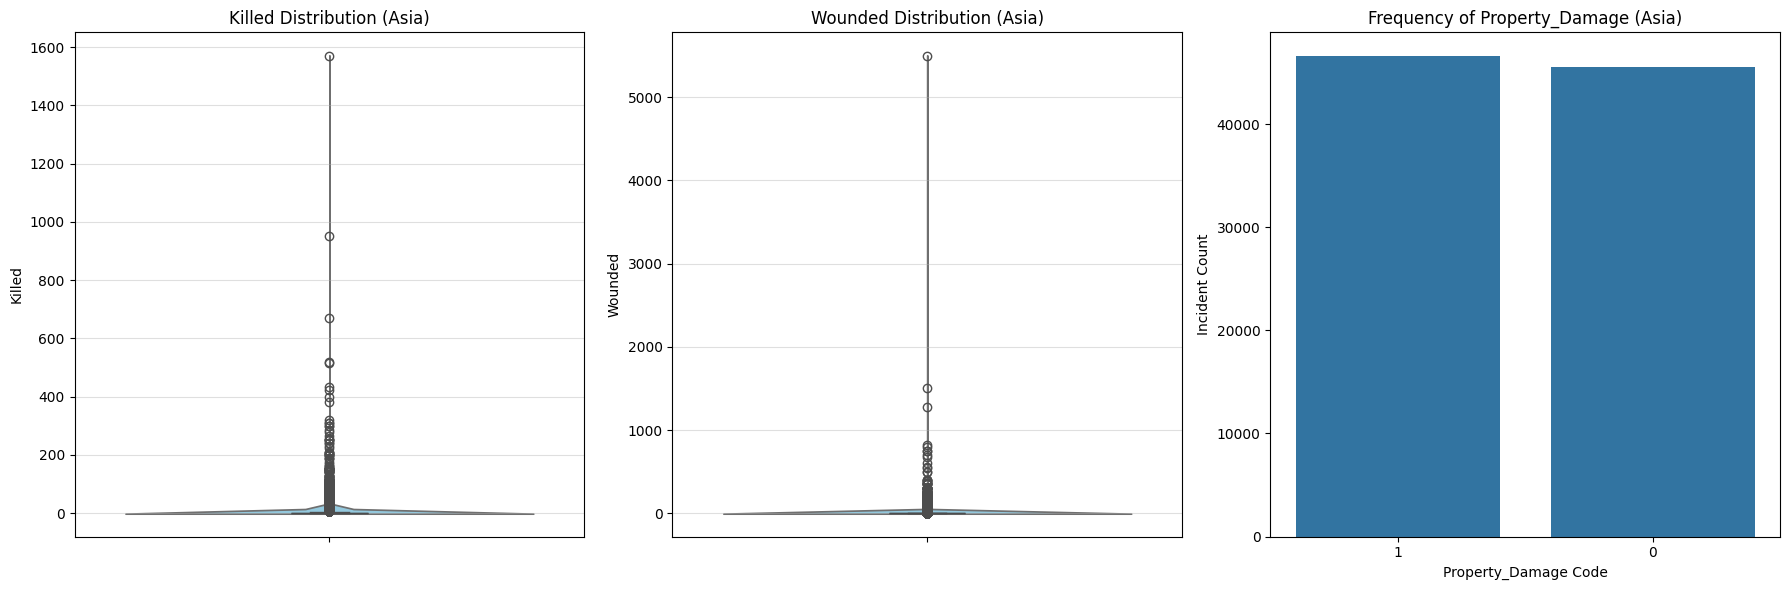

In [60]:
numeric_cols = ['Killed', 'Wounded', 'Property_Damage']

plt.figure(figsize=(18, 6))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    
    if col in ['Killed', 'Wounded']:

        sns.violinplot(y=df_asia[col], inner=None, color='skyblue')
        sns.boxplot(y=df_asia[col], width=0.15, color='orange')
        plt.title(f"{col} Distribution (Asia)")
        plt.grid(axis='y', alpha=0.4)
    
    elif col == 'Property_Damage':

        sns.countplot(
            data=df_asia, 
            x=col, 
            order=df_asia[col].value_counts().index
        )
        plt.title(f"Frequency of {col} (Asia)")
        plt.xlabel(f"{col} Code")
        plt.ylabel('Incident Count')

plt.tight_layout()
plt.show()

Outlier Handling: Log Transformation

In [61]:
df_log = df_asia.copy()


df_log['Log_Killed'] = np.log1p(df_log['Killed'])
df_log['Log_Wounded'] = np.log1p(df_log['Wounded'])
df_log['Log_Total_Casualties'] = np.log1p(df_log['Total_Casualties'])


print("Original Skewness:")
print(df_asia[['Killed', 'Wounded', 'Total_Casualties']].skew())

print("\nLog-Transformed Skewness:")
print(df_log[['Log_Killed', 'Log_Wounded', 'Log_Total_Casualties']].skew())

Original Skewness:
Killed               56.456893
Wounded             144.327288
Total_Casualties     93.976362
dtype: float64

Log-Transformed Skewness:
Log_Killed              1.449205
Log_Wounded             1.454869
Log_Total_Casualties    0.944759
dtype: float64


In [62]:
df_log.to_csv('E:\Global-Terrorism-EDA-Project Final\data\processed data\gtd_log.csv', index=False)
print(df_log)

            Event_ID  Year Month  Day  Extended      Country  \
2       197001000001  1970   JAN   15         0  Philippines   
4       197001000003  1970   JAN   15         0        Japan   
26      197001210001  1970   JAN   21         0  Philippines   
39      197001310001  1970   JAN   31         0  Philippines   
95      197002280001  1970   FEB   28         0       Jordan   
...              ...   ...   ...  ...       ...          ...   
181685  201712310020  2017   DEC   31         0  Afghanistan   
181687  201712310029  2017   DEC   31         0        Syria   
181688  201712310030  2017   DEC   31         0  Philippines   
181689  201712310031  2017   DEC   31         0        India   
181690  201712310032  2017   DEC   31         0  Philippines   

                            Region       State_Province           City  \
2                   Southeast Asia               Tarlac        Unknown   
4                        East Asia              Fukouka        Fukouka   
26       

### **Descriptive Statistics Overview** ##

In [63]:
df_asia[['Killed', 'Wounded', 'Total_Casualties']].describe()

,Killed,Wounded,Total_Casualties
count,109298.000000,109298.000000,109298.00000
mean,2.349082,3.597037,5.94612
std,10.021304,22.386218,26.41517
min,0.000000,0.000000,0.00000
25%,0.000000,0.000000,0.00000
50%,1.000000,0.000000,1.00000
75%,2.000000,3.000000,5.00000
max,1570.000000,5500.000000,5513.00000


In [64]:
# This creates a smaller, shareable file for the "processed" folder
df_asia.to_csv('E:\Global-Terrorism-EDA-Project Final\data\processed data\gtd_asia_cleaned.csv', index=False)
print(df_asia)

            Event_ID  Year Month  Day  Extended      Country  \
2       197001000001  1970   JAN   15         0  Philippines   
4       197001000003  1970   JAN   15         0        Japan   
26      197001210001  1970   JAN   21         0  Philippines   
39      197001310001  1970   JAN   31         0  Philippines   
95      197002280001  1970   FEB   28         0       Jordan   
...              ...   ...   ...  ...       ...          ...   
181685  201712310020  2017   DEC   31         0  Afghanistan   
181687  201712310029  2017   DEC   31         0        Syria   
181688  201712310030  2017   DEC   31         0  Philippines   
181689  201712310031  2017   DEC   31         0        India   
181690  201712310032  2017   DEC   31         0  Philippines   

                            Region       State_Province           City  \
2                   Southeast Asia               Tarlac        Unknown   
4                        East Asia              Fukouka        Fukouka   
26       